# SMS Spam Detector — NLP Pipeline
**Course:** SAIA 2163 — Natural Language Processing  
**Theme:** Theme 4 — Email/SMS Spam Detector  
**Dataset:** SMS Spam Collection (UCI / Kaggle)  
**Group Member:**

*   Cheng Yaxi-A24AI4001
*   Ding Shuna-A24AI4008
*   Yang Zhenhao-A24AI4013
*   Hua Yipin-A24AI4015




                
### Pipeline Overview
1. Load & explore data
2. Text preprocessing
3. Feature extraction (TF-IDF & Bag of Words)
4. Model training & comparison (Naive Bayes & Logistic Regression)
5. Evaluation & visualizations
6. Save models for Streamlit app

## Install & Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

# NLP libraries
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# Models
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

# Evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

# Word cloud
from wordcloud import WordCloud

# Download NLTK data
nltk.download('stopwords')
nltk.download('punkt')

print("All libraries imported successfully!")

All libraries imported successfully!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


## 1. Load & Explore Data (EDA)

In [4]:
# Load the dataset
# The CSV from Kaggle uses latin-1 encoding (not utf-8)
df = pd.read_csv('spam.csv', encoding='latin-1')

# Keep only the two useful columns and rename them
df = df[['v1', 'v2']].rename(columns={'v1': 'label', 'v2': 'text'})

print(f"Dataset shape: {df.shape}")
df.head(10)

Dataset shape: (5572, 2)


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


In [5]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

# Check class distribution
print("\nClass distribution:")
print(df['label'].value_counts())
print(f"\nSpam percentage: {df['label'].value_counts(normalize=True)['spam']*100:.1f}%")

Missing values:
label    0
text     0
dtype: int64

Class distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

Spam percentage: 13.4%


In [6]:
# Add a column for text length (number of characters)
df['text_length'] = df['text'].apply(len)

# Add a column for word count
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

# Compare average text length between spam and ham
print("Average text length:")
print(df.groupby('label')[['text_length', 'word_count']].mean().round(1))

Average text length:
       text_length  word_count
label                         
ham           71.0        14.2
spam         138.9        23.9


In [7]:
# Show some sample spam messages
print("Sample SPAM messages:")
print(df[df['label'] == 'spam']['text'].head(3).values)

print("\nSample HAM messages:")
print(df[df['label'] == 'ham']['text'].head(3).values)

Sample SPAM messages:
["Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's"
 "FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, å£1.50 to rcv"
 'WINNER!! As a valued network customer you have been selected to receivea å£900 prize reward! To claim call 09061701461. Claim code KL341. Valid 12 hours only.']

Sample HAM messages:
['Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...'
 'Ok lar... Joking wif u oni...'
 'U dun say so early hor... U c already then say...']


## 2. Text Preprocessing

In [8]:
# Initialize stemmer and stopwords
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    """
    Clean and normalize a single text string.
    Steps:
    1. Lowercase all characters
    2. Remove special characters, numbers, URLs
    3. Tokenize (split into words)
    4. Remove stopwords (e.g. 'the', 'is', 'and')
    5. Apply stemming (e.g. 'running' -> 'run')
    """
    # Step 1: Convert to lowercase
    text = text.lower()

    # Step 2: Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Step 3: Remove non-alphabet characters (keep only letters and spaces)
    text = re.sub(r'[^a-z\s]', '', text)

    # Step 4: Tokenize — split sentence into individual words
    tokens = text.split()

    # Step 5: Remove stopwords and apply stemming
    tokens = [
        stemmer.stem(word)
        for word in tokens
        if word not in stop_words and len(word) > 1
    ]

    # Join tokens back into a single string
    return ' '.join(tokens)


# Apply preprocessing to all messages
df['clean_text'] = df['text'].apply(preprocess_text)

# Preview before vs after
print("Before preprocessing:")
print(df['text'].iloc[0])
print("\nAfter preprocessing:")
print(df['clean_text'].iloc[0])

Before preprocessing:
Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

After preprocessing:
go jurong point crazi avail bugi great world la buffet cine got amor wat


In [9]:
# Encode labels: spam=1, ham=0
df['label_num'] = df['label'].map({'spam': 1, 'ham': 0})

print("Label encoding:")
print(df[['label', 'label_num']].drop_duplicates())

Label encoding:
  label  label_num
0   ham          0
2  spam          1


## 3. Feature Extraction


In [10]:
# Split data into training set (80%) and testing set (20%)
X = df['clean_text']
y = df['label_num']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")

Training samples : 4457
Testing samples  : 1115


In [11]:
# Feature Extraction Method 1: TF-IDF
# TF-IDF (Term Frequency-Inverse Document Frequency)
# Gives higher weight to words that appear often in one document
# but rarely across all documents — good for identifying key spam words.

tfidf = TfidfVectorizer(max_features=3000)  # Keep top 3000 words

# Fit on training data only, then transform both sets
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f"TF-IDF matrix shape (train): {X_train_tfidf.shape}")

TF-IDF matrix shape (train): (4457, 3000)


In [12]:
# Feature Extraction Method 2: Bag of Words (BoW)
# Bag of Words simply counts how many times each word appears.
# Simpler than TF-IDF but still useful as a baseline comparison.

bow = CountVectorizer(max_features=3000)  # Keep top 3000 words

X_train_bow = bow.fit_transform(X_train)
X_test_bow  = bow.transform(X_test)

print(f"BoW matrix shape (train): {X_train_bow.shape}")

BoW matrix shape (train): (4457, 3000)


## 4. Model Training & Comparison


In [13]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name, feature_name):
    """
    Train a model and return a dictionary of evaluation metrics.
    """
    # Train the model
    model.fit(X_train, y_train)

    # Predict on test set
    y_pred = model.predict(X_test)

    # Calculate metrics
    metrics = {
        'Model': model_name,
        'Features': feature_name,
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall':    round(recall_score(y_test, y_pred), 4),
        'F1-Score':  round(f1_score(y_test, y_pred), 4),
    }

    print(f"\n{'='*50}")
    print(f"  {model_name} + {feature_name}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

    return metrics, y_pred


# Store all results and predictions for later use
results = []
predictions = {}

In [14]:
# Model 1: Naive Bayes
# Naive Bayes is the classic algorithm for text classification.
# It works by calculating the probability that a message is spam
# given the words it contains. Fast and surprisingly effective.

# NB with TF-IDF
nb_tfidf = MultinomialNB()
metrics, preds = evaluate_model(
    nb_tfidf, X_train_tfidf, X_test_tfidf,
    y_train, y_test, 'Naive Bayes', 'TF-IDF'
)
results.append(metrics)
predictions['NB + TF-IDF'] = preds

# NB with BoW
nb_bow = MultinomialNB()
metrics, preds = evaluate_model(
    nb_bow, X_train_bow, X_test_bow,
    y_train, y_test, 'Naive Bayes', 'BoW'
)
results.append(metrics)
predictions['NB + BoW'] = preds


  Naive Bayes + TF-IDF
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       966
        Spam       0.99      0.78      0.87       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115


  Naive Bayes + BoW
              precision    recall  f1-score   support

         Ham       0.98      0.99      0.99       966
        Spam       0.92      0.89      0.90       149

    accuracy                           0.97      1115
   macro avg       0.95      0.94      0.94      1115
weighted avg       0.97      0.97      0.97      1115



In [15]:
# Model 2: Logistic Regression
# Logistic Regression learns a weight for each word.
# Positive weight → pushes towards spam, negative → towards ham.
# Easy to interpret and usually performs very well on text data.

# LR with TF-IDF
lr_tfidf = LogisticRegression(max_iter=1000, random_state=42)
metrics, preds = evaluate_model(
    lr_tfidf, X_train_tfidf, X_test_tfidf,
    y_train, y_test, 'Logistic Regression', 'TF-IDF'
)
results.append(metrics)
predictions['LR + TF-IDF'] = preds

# LR with BoW
lr_bow = LogisticRegression(max_iter=1000, random_state=42)
metrics, preds = evaluate_model(
    lr_bow, X_train_bow, X_test_bow,
    y_train, y_test, 'Logistic Regression', 'BoW'
)
results.append(metrics)
predictions['LR + BoW'] = preds


  Logistic Regression + TF-IDF
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       966
        Spam       0.98      0.77      0.86       149

    accuracy                           0.97      1115
   macro avg       0.97      0.88      0.92      1115
weighted avg       0.97      0.97      0.97      1115


  Logistic Regression + BoW
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       966
        Spam       1.00      0.87      0.93       149

    accuracy                           0.98      1115
   macro avg       0.99      0.93      0.96      1115
weighted avg       0.98      0.98      0.98      1115



In [16]:
# Summary comparison table of all model results
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)
print("Model Comparison Summary:")
results_df

Model Comparison Summary:


,Model,Features,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,BoW,0.9821,1.0000,0.8658,0.9281
1,Naive Bayes,BoW,0.9749,0.9231,0.8859,0.9041
2,Naive Bayes,TF-IDF,0.9695,0.9915,0.7785,0.8722
3,Logistic Regression,TF-IDF,0.9677,0.9829,0.7718,0.8647


## 5. Visualizations

In [17]:
# Create output folder for saving figures
os.makedirs('../data/figures', exist_ok=True)

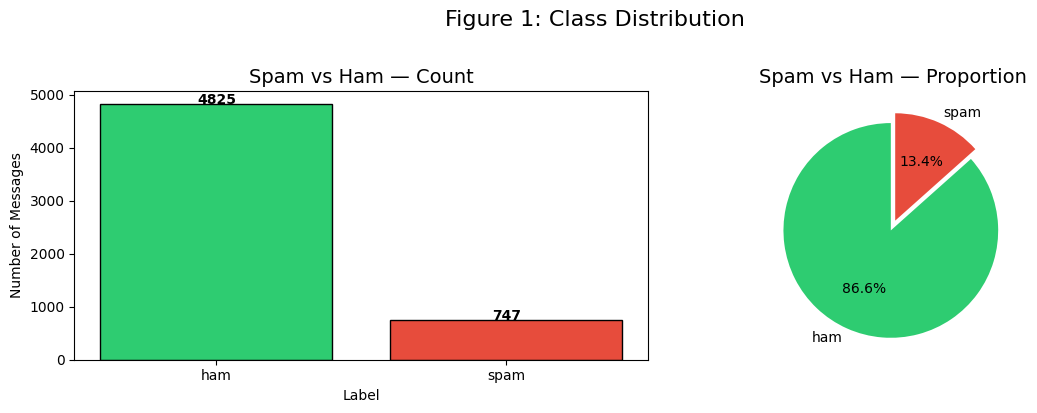

In [18]:
# Visualization 1: Class Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['label'].value_counts()

# Bar chart
axes[0].bar(counts.index, counts.values, color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Spam vs Ham — Count', fontsize=14)
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Number of Messages')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(
    counts.values,
    labels=counts.index,
    autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c'],
    startangle=90,
    explode=(0.05, 0.05)
)
axes[1].set_title('Spam vs Ham — Proportion', fontsize=14)

plt.suptitle('Figure 1: Class Distribution', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('../data/figures/fig1_class_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

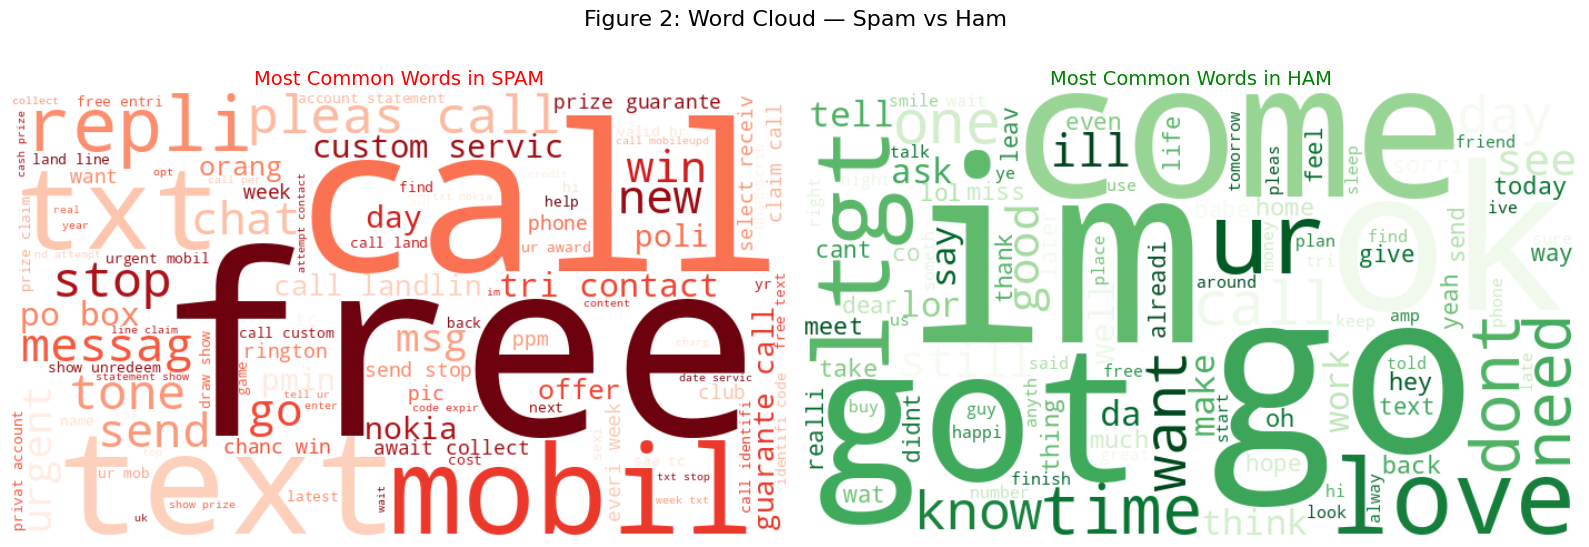

In [19]:
# Visualization 2: Word Cloud
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Word cloud for spam messages
spam_text = ' '.join(df[df['label'] == 'spam']['clean_text'])
wc_spam = WordCloud(
    width=700, height=400,
    background_color='white',
    colormap='Reds',
    max_words=100
).generate(spam_text)
axes[0].imshow(wc_spam, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Most Common Words in SPAM', fontsize=14, color='red')

# Word cloud for ham messages
ham_text = ' '.join(df[df['label'] == 'ham']['clean_text'])
wc_ham = WordCloud(
    width=700, height=400,
    background_color='white',
    colormap='Greens',
    max_words=100
).generate(ham_text)
axes[1].imshow(wc_ham, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Most Common Words in HAM', fontsize=14, color='green')

plt.suptitle('Figure 2: Word Cloud — Spam vs Ham', fontsize=16)
plt.tight_layout()
plt.savefig('../data/figures/fig2_wordcloud.png', bbox_inches='tight', dpi=150)
plt.show()

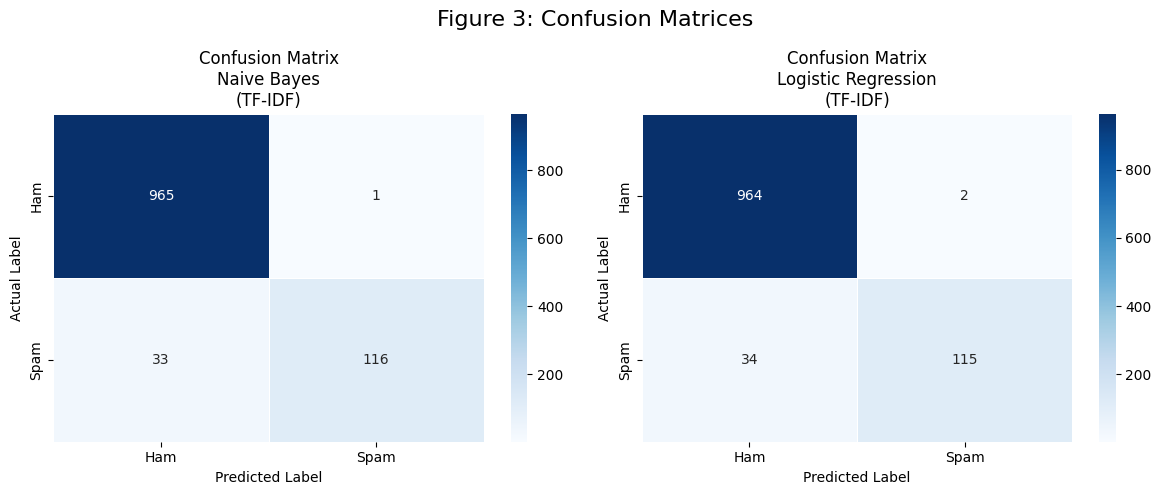

In [20]:
# Visualization 3: Confusion Matrix
# Show confusion matrix for the two best models (NB and LR using TF-IDF)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

best_combos = [
    ('NB + TF-IDF',  'Naive Bayes\n(TF-IDF)'),
    ('LR + TF-IDF',  'Logistic Regression\n(TF-IDF)'),
]

for ax, (key, title) in zip(axes, best_combos):
    cm = confusion_matrix(y_test, predictions[key])
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Ham', 'Spam'],
        yticklabels=['Ham', 'Spam'],
        ax=ax, linewidths=0.5
    )
    ax.set_title(f'Confusion Matrix\n{title}', fontsize=12)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('Actual Label')

plt.suptitle('Figure 3: Confusion Matrices', fontsize=16)
plt.tight_layout()
plt.savefig('../data/figures/fig3_confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

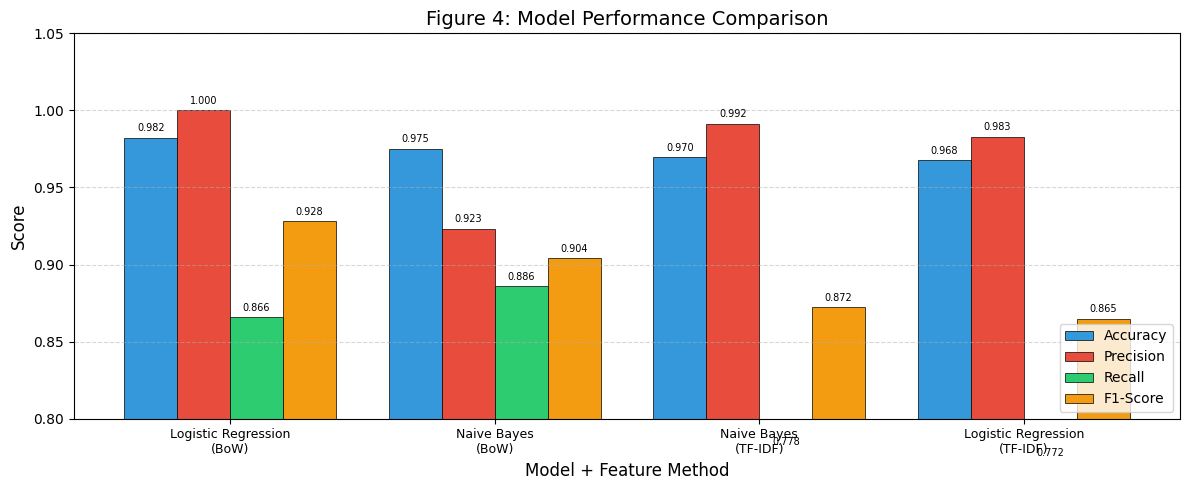

In [21]:
# Visualization 4: Model Comparison Bar Chart
fig, ax = plt.subplots(figsize=(12, 5))

# Prepare data for grouped bar chart
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(results_df))
width = 0.2
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for i, metric in enumerate(metrics_to_plot):
    bars = ax.bar(
        x + i * width,
        results_df[metric],
        width,
        label=metric,
        color=colors[i],
        edgecolor='black',
        linewidth=0.5
    )
    # Add value labels on top of bars
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.003,
            f'{h:.3f}',
            ha='center', va='bottom', fontsize=7
        )

ax.set_xlabel('Model + Feature Method', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Figure 4: Model Performance Comparison', fontsize=14)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(
    [f"{r['Model']}\n({r['Features']})" for _, r in results_df.iterrows()],
    fontsize=9
)
ax.set_ylim(0.8, 1.05)
ax.legend(loc='lower right')
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('../data/figures/fig4_model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

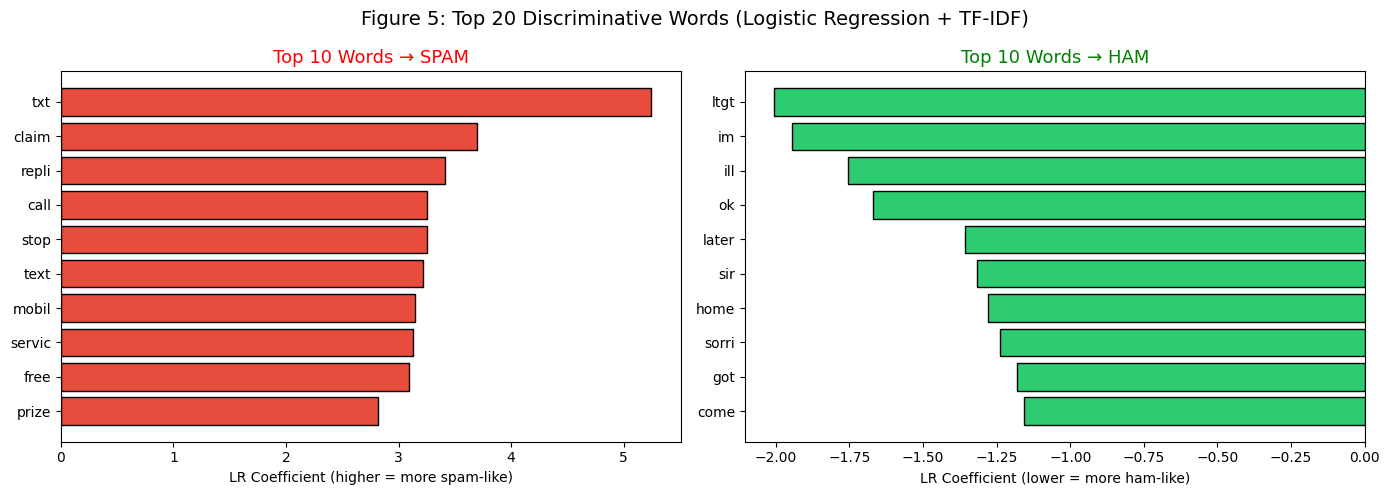

In [22]:
# Visualization 5: Top 20 Most Important Words (TF-IDF)
# Extract the top spam-indicator words from Logistic Regression coefficients
# Positive coefficient = more likely spam; Negative = more likely ham

feature_names = np.array(tfidf.get_feature_names_out())
# Get coefficients from the LR model trained with TF-IDF
coef = lr_tfidf.coef_[0]

# Top 10 spam words (highest positive coefficients)
top_spam_idx = np.argsort(coef)[-10:][::-1]
top_spam_words = feature_names[top_spam_idx]
top_spam_scores = coef[top_spam_idx]

# Top 10 ham words (most negative coefficients)
top_ham_idx = np.argsort(coef)[:10]
top_ham_words = feature_names[top_ham_idx]
top_ham_scores = coef[top_ham_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Spam words
axes[0].barh(top_spam_words[::-1], top_spam_scores[::-1], color='#e74c3c', edgecolor='black')
axes[0].set_title('Top 10 Words → SPAM', fontsize=13, color='red')
axes[0].set_xlabel('LR Coefficient (higher = more spam-like)')

# Ham words
axes[1].barh(top_ham_words[::-1], top_ham_scores[::-1], color='#2ecc71', edgecolor='black')
axes[1].set_title('Top 10 Words → HAM', fontsize=13, color='green')
axes[1].set_xlabel('LR Coefficient (lower = more ham-like)')

plt.suptitle('Figure 5: Top 20 Discriminative Words (Logistic Regression + TF-IDF)', fontsize=14)
plt.tight_layout()
plt.savefig('../data/figures/fig5_top_words.png', bbox_inches='tight', dpi=150)
plt.show()

## 6. Save Best Model for Streamlit App

In [23]:
# Create models folder if it does not exist
os.makedirs('../models', exist_ok=True)

# Save the best model (Logistic Regression + TF-IDF)
# The Streamlit app will load these files to make predictions
joblib.dump(lr_tfidf, '../models/lr_model.pkl')
joblib.dump(tfidf,    '../models/tfidf_vectorizer.pkl')

# Also save the Naive Bayes model for comparison in the app
joblib.dump(nb_tfidf, '../models/nb_model.pkl')

print("Models saved successfully!")
print("  → ../models/lr_model.pkl")
print("  → ../models/nb_model.pkl")
print("  → ../models/tfidf_vectorizer.pkl")

Models saved successfully!
  → ../models/lr_model.pkl
  → ../models/nb_model.pkl
  → ../models/tfidf_vectorizer.pkl


In [24]:
# Quick test: verify the saved model works correctly
test_messages = [
    "Congratulations! You have won a FREE prize. Call now to claim!",  # Should be spam
    "Hey, are we still meeting for lunch tomorrow?",                    # Should be ham
    "URGENT: Your account will be suspended. Click here immediately!",  # Should be spam
]

# Load model back from disk and test
loaded_model     = joblib.load('../models/lr_model.pkl')
loaded_vectorizer = joblib.load('../models/tfidf_vectorizer.pkl')

for msg in test_messages:
    cleaned = preprocess_text(msg)
    vec     = loaded_vectorizer.transform([cleaned])
    pred    = loaded_model.predict(vec)[0]
    prob    = loaded_model.predict_proba(vec)[0]
    label   = 'SPAM' if pred == 1 else 'HAM'
    conf    = prob[1] if pred == 1 else prob[0]
    print(f"[{label}] ({conf:.1%} confidence) — {msg[:60]}...")

[SPAM] (94.5% confidence) — Congratulations! You have won a FREE prize. Call now to clai...
[HAM] (98.6% confidence) — Hey, are we still meeting for lunch tomorrow?...
[HAM] (64.2% confidence) — URGENT: Your account will be suspended. Click here immediate...


## Summary

| Step | What we did |
|------|-------------|
| Data | Loaded SMS Spam Collection (5,572 messages) |
| Preprocessing | Lowercase, remove special chars, remove stopwords, stemming |
| Feature Extraction 1 | TF-IDF (top 3000 features) |
| Feature Extraction 2 | Bag of Words (top 3000 features) |
| Model 1 | Naive Bayes |
| Model 2 | Logistic Regression |
| Best Model | Logistic Regression + TF-IDF (saved to `/models/`) |
| Visualizations | 6 figures saved to `/data/figures/` |